In [ ]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.power import FTestAnovaPower
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Create Synthetic Dataset

In [174]:
# set the number of rows
n = 80

# generate the data set

# create the categorical variables
# create the constant of 1 virus
virus = ['Influenza_B'] * n

# create the surfaces in the data set by assigning each equaly
surface = ["Stainless_Steel"] * 20 + ["Plastic"] * 20 + ["Granite"] * 20 + ["Glass"] * 20

# create the options for disinfectant
# need to select the two things equaly within each value of surface
disinfectant = []
for i in range(4):
    disinfectant.extend(["Control"] * 10 + ["Disinfectant"] * 10)

# create the application method
application = []
for i in range(8):
    application.extend(["Wipes"] * 5 + ["Spray"] * 5)

# create dataframe containing the categorical variables
df = pd.DataFrame({
    "Virus": virus,
    "Surface": surface,
    "Disinfectant": disinfectant,
    "Application" : application
})

# create continuous variables and add them to the dataframe
# use random seed to ensure replicability
np.random.seed(42)

# create the random values for temperature
df["Temperature_Celsius"] = np.random.uniform(17, 27, 80)
df["Temperature_Celsius"] = df["Temperature_Celsius"].round(2) # add to data frame and round

# function to create the random values for porosity based on surface
def get_porosity(surface):
    if surface == "Stainless_Steel":
        return np.random.uniform(0,0.2) #range determined from avg porosity of stainless steel
    elif surface == "Plastic":
        return 0
    elif surface == "Granite":
        return np.random.uniform(0.05,1.5) # range determined from avg. porosity of granite
    else:
        return 0

df['Porosity'] = df['Surface'].apply(get_porosity) #run function using surface as input
df['Porosity'] = df['Porosity'].round(2) #add to dataframe and round


# create random values for time based on all input variables

# set seed for reproducibility
np.random.seed(42)

# empty list
time_list = []


# loop to create all time values based on inputs
for i, row in df.iterrows():
    if row["Disinfectant"] == "Control":
        # control: 24–48 h in minutes
        if row["Surface"] == "Stainless_Steel":
            time = np.random.randint(1900, 2100)
        elif row["Surface"] == "Plastic":
            time = np.random.randint(1800, 2000)
        elif row["Surface"] == "Granite":
            time = np.random.randint(2000, 2200)
        else:  # glass
            time = np.random.randint(1850, 2050)

    else:
        # disinfectant: spray slightly faster than wipes
        if row["Surface"] == "Stainless_Steel":
            if row["Application"] == "Wipes":
                time = np.random.randint(8, 14)
            elif row["Application"] == "Spray":
                time = np.random.randint(2, 5)

        elif row["Surface"] == "Plastic":
            if row["Application"] == "Wipes":
                time = np.random.randint(8, 13)
            elif row["Application"] == "Spray":
                time = np.random.randint(2, 6)

        elif row["Surface"] == "Granite":
            if row["Application"] == "Wipes":
                time = np.random.randint(10, 15)
            elif row["Application"] == "Spray":
                time = np.random.randint(3, 7)

        else:  # glass
            if row["Application"] == "Wipes":
                time = np.random.randint(8, 12)
            elif row["Application"] == "Spray":
                time = np.random.randint(2, 5)
                
    #add explicit application significance
    if row["Application"] == "Spray" and row["Disinfectant"] == "Disinfectant":
        time = max(1, time - 4)

    time_list.append(time)
# assign time values to the dataframe
df["Time"] = time_list

# add new columns for crossover/washout RCT

# create empty lists
application_2_list = []
time_2_list = []

# assign new applications that are opposite of original application
for i, row in df.iterrows():

    # flip application
    if row["Application"] == "Wipes":
        app2 = "Spray"
    else:
        app2 = "Wipes"

    application_2_list.append(app2)

    # create Time_2
    time2 = row["Time"]

    if app2 == "Spray":
        time2 = time2 + 2.0 #ensure slight effect that spray to wipes is better than wipes to spray

    time_2_list.append(time2)

# add new columns to dataframe
df["Application_2"] = application_2_list
df["Time_2"] = time_2_list

# add new columns for withdrawal RCT

# subset data to only use the 'Disinfectant' rows
df_w = df[df["Disinfectant"] == "Disinfectant"].copy()

# assign withdrawal status (50/50 split)
np.random.seed(42)
mask = np.random.rand(len(df_w)) < 0.5
df_w['Withdrawal_Status'] = np.where(mask, 'Continued', 'Withdrawn')

# generate viral load data (T1 = baseline, T2 = after withdrawal period)
df_w['Viral_Load_T1'] = np.random.uniform(5, 15, len(df_w))

def calculate_rebound(row):
    if row['Withdrawal_Status'] == 'Withdrawn':
        # High rebound because disinfectant was stopped
        return row['Viral_Load_T1'] + np.random.uniform(100, 300)
    else:
        # Low rebound because disinfectant continued
        return row['Viral_Load_T1'] + np.random.uniform(0, 20)

df_w['Viral_Load_T2'] = df_w.apply(calculate_rebound, axis=1)

# merge subset data back to original df
# merging creates NaN for original Control group rows
df = df.merge(
    df_w[['Withdrawal_Status', 'Viral_Load_T1', 'Viral_Load_T2']],
    left_index=True,
    right_index=True,
    how='left'
)


# create matched pairs for matched pairs RCT

# shuffle data to avoid pairing bias
np.random.seed(42)
df = df.sample(frac=1).reset_index(drop=True)

# create empty column
df["Pair_ID"] = np.nan

pair_id = 1 #set starting pair id

# group by the controlled variables
for (surface, application), group in df.groupby(["Surface", "Application"]):
    
    # separate treatment and control
    control_rows = group[group["Disinfectant"] == "Control"].index.tolist()
    treat_rows = group[group["Disinfectant"] == "Disinfectant"].index.tolist()
    
    # ensure equal matching
    n_pairs = min(len(control_rows), len(treat_rows))
    
    for i in range(n_pairs):
        df.loc[control_rows[i], "Pair_ID"] = pair_id
        df.loc[treat_rows[i], "Pair_ID"] = pair_id
        pair_id += 1

# convert to integer
df["Pair_ID"] = df["Pair_ID"].astype("Int64")



df.head(25)

,Virus,Surface,Disinfectant,Application,Temperature_Celsius,Porosity,Time,Application_2,Time_2,Withdrawal_Status,Viral_Load_T1,Viral_Load_T2,Pair_ID
0,Influenza_B,Plastic,Disinfectant,Wipes,23.08,0.00,10,Spray,12.0,Continued,14.695846,17.087731,26
1,Influenza_B,Stainless_Steel,Control,Wipes,20.75,0.17,2002,Spray,2004.0,NaN,NaN,NaN,36
2,Influenza_B,Plastic,Control,Wipes,19.92,0.00,1991,Spray,1993.0,NaN,NaN,NaN,26
3,Influenza_B,Plastic,Disinfectant,Wipes,18.71,0.00,10,Spray,12.0,Withdrawn,12.751328,255.400286,27
4,Influenza_B,Stainless_Steel,Disinfectant,Spray,21.32,0.01,1,Wipes,1.0,Withdrawn,10.467103,287.909651,31
5,Influenza_B,Plastic,Control,Spray,22.92,0.00,1888,Wipes,1888.0,NaN,NaN,NaN,21
6,Influenza_B,Stainless_Steel,Disinfectant,Wipes,17.21,0.02,10,Spray,12.0,Continued,6.220382,23.482451,36
7,Influenza_B,Glass,Disinfectant,Wipes,24.72,0.00,11,Spray,13.0,Withdrawn,12.722448,170.672738,6
8,Influenza_B,Stainless_Steel,Control,Wipes,18.56,0.06,2006,Spray,2008.0,NaN,NaN,NaN,37
9,Influenza_B,Stainless_Steel,Disinfectant,Wipes,25.32,0.15,10,Spray,12.0,Withdrawn,5.343885,171.523490,37


## Exploratory Data Analysis

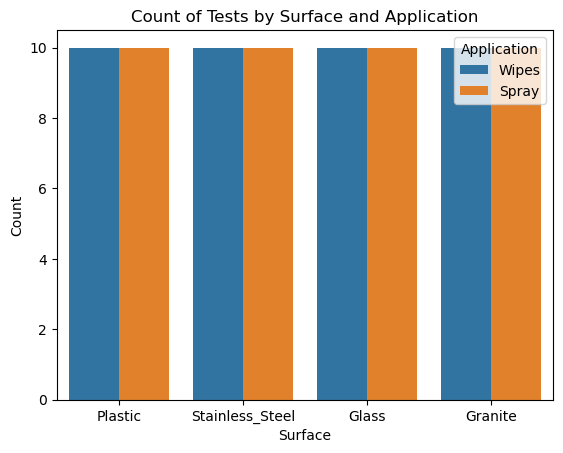

In [175]:
sns.countplot(x="Surface", hue="Application", data = df)

plt.title('Count of Tests by Surface and Application')
plt.ylabel('Count')
plt.xlabel('Surface')
plt.show()

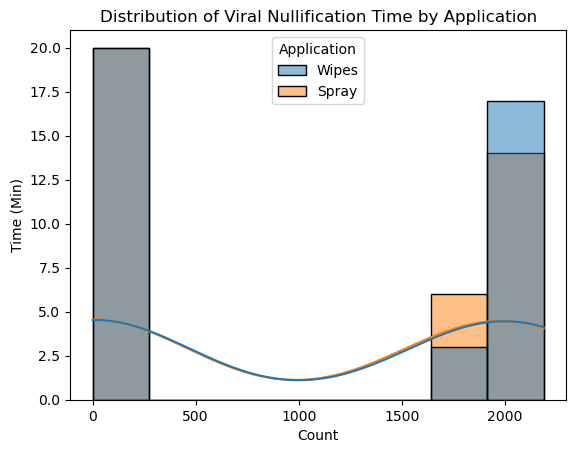

In [176]:
# histogram for time?
sns.histplot(x="Time", kde=True, hue="Application" ,data=df)

plt.title('Distribution of Viral Nullification Time by Application')
plt.ylabel('Time (Min)')
plt.xlabel('Count')
plt.show()

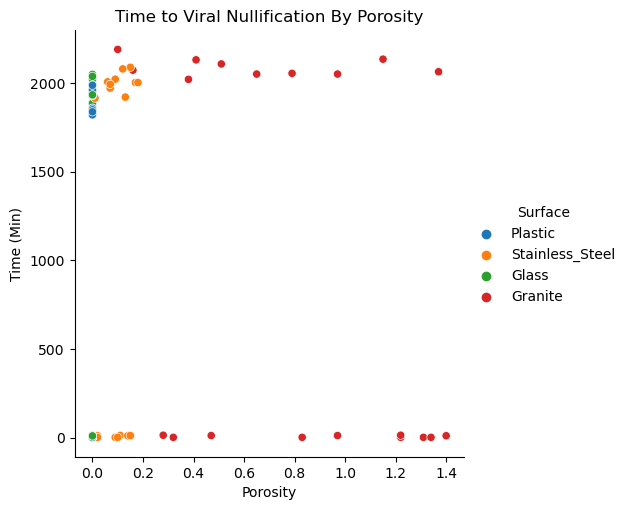

In [177]:
# Scatter plot to visualize relationship between porosiy, surface, application and time
sns.relplot(data=df, x='Porosity', y='Time', hue='Surface')

plt.title('Time to Viral Nullification By Porosity')
plt.ylabel('Time (Min)')
plt.xlabel('Porosity')
plt.show()

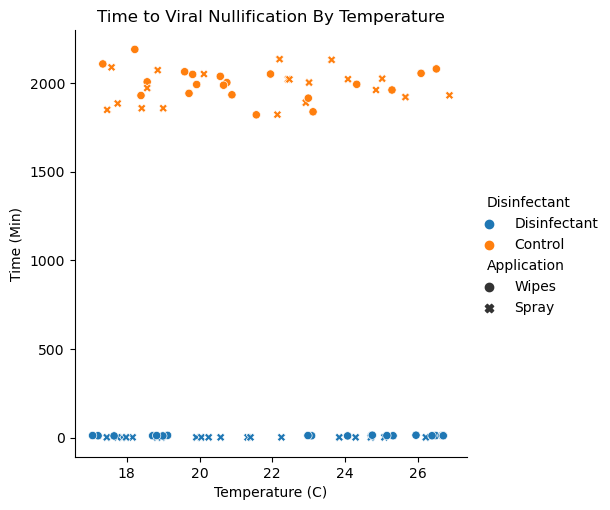

In [178]:
#Time vs Tempature with Surface 
sns.relplot(data=df, x='Temperature_Celsius', y='Time', hue="Disinfectant", style='Application')


plt.title('Time to Viral Nullification By Temperature')
plt.ylabel('Time (Min)')
plt.xlabel('Temperature (C)')
plt.show()




In [179]:
# Create long dataframe for visualization of the viral load across time

# select the relevant columns
df_plot = df[['Viral_Load_T1', 'Viral_Load_T2', 'Withdrawal_Status']].copy()

# drop rows with nulls
df_plot = df_plot.dropna(subset=['Viral_Load_T1', 'Viral_Load_T2'])

# melt T1 and T2 into one column
df_long = pd.melt(
    df_plot,
    id_vars=['Withdrawal_Status'], 
    value_vars=['Viral_Load_T1', 'Viral_Load_T2'],
    var_name='Time_Point',        
    value_name='Viral_Load'            
)

# rename for clarity
df_long['Time_Point'] = df_long['Time_Point'].map({'Viral_Load_T1': 'T1', 'Viral_Load_T2': 'T2'})



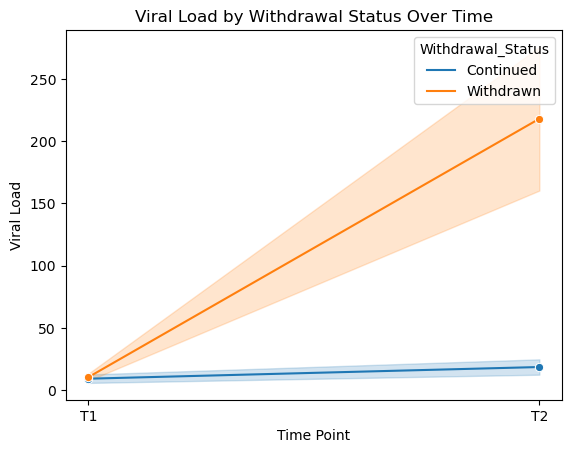

In [180]:
#Viral Load vs Withdrawl Status

sns.lineplot(
    data=df_long,
    x='Time_Point',
    y='Viral_Load',
    hue='Withdrawal_Status',  
    marker='o',
    errorbar="sd"
)

plt.title('Viral Load by Withdrawal Status Over Time')
plt.ylabel('Viral Load')
plt.xlabel('Time Point')
plt.show()

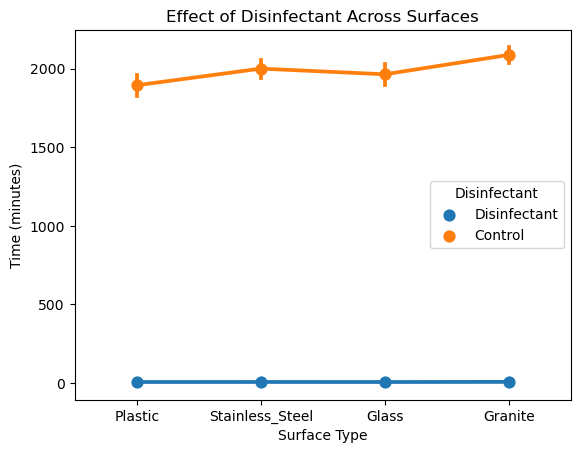

In [181]:

#Disinfectant vs Surface 

sns.pointplot(
    data=df,
    x="Surface",
    y="Time",
    hue="Disinfectant",
    errorbar="sd"
)

plt.title("Effect of Disinfectant Across Surfaces")
plt.ylabel("Time (minutes)")
plt.xlabel("Surface Type")

plt.show()

## Parallel Randomized Control Trial

In [182]:
# Subset data for Parallel RCT
df_parallel = df[[
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Temperature_Celsius",
    "Porosity",
    "Time"
]].copy()

### Hypothesis
Main Effect Disinfectant:  
H0: There is no difference in mean time to nullify the virus between disinfectant and control treatments.  
H1: There is a difference in mean time to nullify the virus between disinfectant and control treatments.
    
Main Effect Application:  
H0: There is no difference in mean time to nullify the virus between spray and wipe application.  
H1: There is a difference in mean time to nullify the virus between spray and wipe application.  
  
Interaction Effect:   Disinfectant x Application  
H0: There is no interaction between disinfectant and application method on mean time to nullify the virus.  
H1: There is an interaction between disinfectant and application method on mean time to nullify the virus.


### ANOVA
##### Testing the interaction between Disinfectant and Application Method

In [183]:
#ANOVA 1: Testing the interaction between Disinfectant and Application Method
# This checks if 'Spray' vs 'Wipes' actually changes the 'Time' outcome  differently depending on whether it's a Control or Disinfectant.
model_anova1 = smf.ols("Time ~ C(Disinfectant) * C(Application)", data=df_parallel).fit()
anova_results_1 = anova_lm(model_anova1, typ=2)

print("\nANOVA 1: Disinfectant * Application")
print(anova_results_1)


ANOVA 1: Disinfectant * Application
                                     sum_sq    df             F        PR(>F)
C(Disinfectant)                 78415920.20   1.0  18452.672872  1.793936e-92
C(Application)                      5024.45   1.0      1.182343  2.803160e-01
C(Disinfectant):C(Application)       768.80   1.0      0.180912  6.717922e-01
Residual                          322967.30  76.0           NaN           NaN


### Pairwise Tukey Test

In [184]:
# Tukey HSD for Application
tukey_app = pairwise_tukeyhsd(
    endog=df["Time"], #continuous outcome
    groups=df["Application"], #grouping variable
    alpha=0.05
)

print(tukey_app)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
 Spray  Wipes    15.85 0.9439 -431.4227 463.1227  False
-------------------------------------------------------


### Power Analysis

In [185]:
import numpy as np
from statsmodels.stats.power import FTestAnovaPower

# Groups by application
groups = [
    df_parallel[df_parallel["Application"] == "Wipes"]["Time"].values,
    df_parallel[df_parallel["Application"] == "Spray"]["Time"].values,
]

# Grand mean
data = np.concatenate(groups)
grand_mean = np.mean(data)

# Sum of squares between groups
ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)

# Sum of squares within groups
ss_within = sum(np.sum((g - np.mean(g)) ** 2) for g in groups)

# Cohen's f
effect_size = np.sqrt(ss_between / ss_within)
print(f"Cohen's f (Application effect): {effect_size:.2f}")

# Power analysis
power_analysis = FTestAnovaPower()

sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=0.05,
    k_groups=2   # Wipes vs Spray
)

print(f"Required sample size per group: {sample_size:.0f}")

Cohen's f (Application effect): 0.01
Required sample size per group: 123003


## Factorial Randomized Control Trial

In [186]:
# subset dataset for factorial RCT
df_factorial = df[[
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Temperature_Celsius",
    "Porosity",
    "Time"
]].copy()

#df[df["Disinfectant"] == "Disinfectant"].copy()


### Hypothesis
Main Effect Disinfectant:  
H0: There is no difference in mean time to nullify the virus between disinfectant and control treatments.  
H1: There is a difference in mean time to nullify the virus between disinfectant and control treatments.
    
Main Effect Application Method:  
H0: There is no difference in mean time to nullify the virus between spray and wipe application.  
H1: There is a difference in mean time to nullify the virus between spray and wipe application. 
   
Main Effect Surface:  
H0: There is no difference in mean time to nullify the virus between surfaces.  
H1: There is a difference in mean time to nullify the virus between surfaces.  
  
Interaction Effect Application x Surface:  
H0: There is no interaction between application method and surface, the effect of application method on time to nullify the virus is the same for all surfaces.  
H1: There is an interaction between application method and surface, the effect of application method on time to nullify the virus depends on the surface type.


### ANOVA
##### Testing the factorial interaction between Disinfectant Application Method and Surface

In [187]:
# two-way factorial ANOVA

# We use 'Time' as the dependent variable to see if disinfectant application effectiveness depends on the specific surface it's applied to.
model = smf.ols('Time ~ C(Disinfectant) + C(Application) + C(Surface) + C(Application):C(Surface)',
            data=df_factorial).fit()

anova_table = anova_lm(model, typ=2)
print("Two-way Factorial ANOVA Table:\n")
print(anova_table)

Two-way Factorial ANOVA Table:

                                sum_sq    df             F        PR(>F)
C(Disinfectant)            78415920.20   1.0  24787.720914  4.524395e-92
C(Application)                 5024.45   1.0      1.588257  2.117016e-01
C(Surface)                    97586.25   3.0     10.282524  1.055061e-05
C(Application):C(Surface)      1541.45   3.0      0.162420  9.213025e-01
Residual                     224608.40  71.0           NaN           NaN


### Pairwise Tukey Test

In [ ]:
# Post-hoc Tukey HSD

# Create combined group column
df_factorial['App_Surface'] = df_factorial['Application'] + "_" + df_factorial['Surface']


# Melt the dataframe
df_melt_fact = pd.melt(df_factorial.reset_index(), 
                  id_vars=['index'], 
                  value_vars=['Time'])

# Rename columns for clarity
df_melt_fact.columns = ['index', 'treatments', 'value']

# Replace 'treatments' with the actual group labels
df_melt_fact['treatments'] = df_factorial['App_Surface'].values


# Run pairwise Tukey HSD
hs_res = pairwise_tukeyhsd(endog=df_melt_fact["value"], 
                           groups=df_melt_fact['treatments'], 
                           alpha=0.05)

print(hs_res)

### Power Analysis

In [ ]:
# conduct power analysis calculating effect size from data
# Create groupings by surface
groups = [
    group["Time"].dropna()
    for _, group in df_factorial.groupby(["Surface", "Application"])
]

# Calculate mean of combined data
dataFact = np.concatenate(groups)
dataFact_mean = np.mean(dataFact)

# Calculate sum of squares between groups
ss_between = sum(
    len(group) * (np.mean(group) - dataFact_mean) ** 2
    for group in groups
)

# Calculate sum of squares within groups
ss_within = sum(
    np.sum((group - np.mean(group)) ** 2)
    for group in groups
)

# Calculate effect size using Cohen's f
effect_size = np.sqrt(ss_between / ss_within)

# Display effect size result
print(f'Effect size: {effect_size:.2f}')

# Conduct power analysis
power_analysis = FTestAnovaPower()
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=0.05,
    k_groups=8
)

# Display power analysis result
print(f'The sample size required per group is: {sample_size:.0f}')

Effect size: 0.04
The sample size required per group is: 10842


## Crossover Randomized Control Trial

### Subset the Data

In [ ]:
# subset data to create new data set crossover RCT
df_crossover = df[[
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Time",
    "Application_2",
    "Time_2"
]].copy()

df_crossover.head(10)

,Virus,Surface,Disinfectant,Application,Time,Application_2,Time_2
0,Influenza_B,Plastic,Disinfectant,Wipes,10,Spray,12.0
1,Influenza_B,Stainless_Steel,Control,Wipes,2002,Spray,2004.0
2,Influenza_B,Plastic,Control,Wipes,1991,Spray,1993.0
3,Influenza_B,Plastic,Disinfectant,Wipes,10,Spray,12.0
4,Influenza_B,Stainless_Steel,Disinfectant,Spray,1,Wipes,1.0
5,Influenza_B,Plastic,Control,Spray,1888,Wipes,1888.0
6,Influenza_B,Stainless_Steel,Disinfectant,Wipes,10,Spray,12.0
7,Influenza_B,Glass,Disinfectant,Wipes,11,Spray,13.0
8,Influenza_B,Stainless_Steel,Control,Wipes,2006,Spray,2008.0
9,Influenza_B,Stainless_Steel,Disinfectant,Wipes,10,Spray,12.0


In [ ]:
# filter to only disinfectant rows — crossover of application
# method (wipes vs spray) is only meaningful when disinfectant is applied
df_crossover = df_crossover[df_crossover["Disinfectant"] == "Disinfectant"].copy()

# create a Sequence column to track the order of treatments
# e.g. "Wipes_then_Spray" or "Spray_then_Wipes"
df_crossover["Sequence"] = (
    df_crossover["Application"] + "_then_" + df_crossover["Application_2"]
)

# reshape data to long format (one row per subject per period)
# this is needed because in a crossover design, each subject
# receives BOTH treatments across two time periods

# Period 1: original application and time
df_period1 = df_crossover[["Surface", "Application", "Time", "Sequence"]].copy()
df_period1.rename(columns={"Application": "Treatment", "Time": "Outcome"}, inplace=True)
df_period1["Period"] = "Period_1"

# Period 2: crossover application and time
df_period2 = df_crossover[["Surface", "Application_2", "Time_2", "Sequence"]].copy()
df_period2.rename(columns={"Application_2": "Treatment", "Time_2": "Outcome"}, inplace=True)
df_period2["Period"] = "Period_2"

# combine into one long dataframe
df_crossover_long = pd.concat([df_period1, df_period2], ignore_index=True)

print("Crossover long format shape:", df_crossover_long.shape)
df_crossover_long.head(10)

Crossover long format shape: (80, 5)


,Surface,Treatment,Outcome,Sequence,Period
0,Plastic,Wipes,10.0,Wipes_then_Spray,Period_1
1,Plastic,Wipes,10.0,Wipes_then_Spray,Period_1
2,Stainless_Steel,Spray,1.0,Spray_then_Wipes,Period_1
3,Stainless_Steel,Wipes,10.0,Wipes_then_Spray,Period_1
4,Glass,Wipes,11.0,Wipes_then_Spray,Period_1
5,Stainless_Steel,Wipes,10.0,Wipes_then_Spray,Period_1
6,Plastic,Wipes,11.0,Wipes_then_Spray,Period_1
7,Plastic,Spray,1.0,Spray_then_Wipes,Period_1
8,Glass,Wipes,11.0,Wipes_then_Spray,Period_1
9,Granite,Spray,1.0,Spray_then_Wipes,Period_1


### Hypothesis
Main Effect Treatment:  
H0: The mean time to nullify the virus is the same for wipes and spray, regardless of the period.  
H1: The mean time to nullify the virus differs between wipes and spray.  
   
Main Effect of Period:  
H0: The mean time to nullify the virus is the same in Period 1 and Period 2, regardless of the treatment (wipe vs. spray).  
H1: The mean time to nullify the virus differs between Period 1 and Period 2.  
  
Interaction Effect Treatment  x Period:  
H0: The effect of treatment is consistent across periods.  
H1: The effect of treatment differs depending on the period.

### ANOVA
##### Testing the factorial interaction between Disinfectant Application Method and Surface

In [ ]:
# two-way ANOVA for crossover design
# Factor 1: Treatment (Wipes vs Spray) — the actual method used
# Factor 2: Period (Period_1 vs Period_2) — checks for carryover effects
# Interaction: does the treatment effect change depending on the period?
model_crossover = smf.ols(
    "Outcome ~ C(Treatment) * C(Period)",
    data=df_crossover_long
).fit()

anova_crossover = anova_lm(model_crossover, typ=2)

print("Two-way ANOVA: Treatment * Period (Crossover RCT)\n")
print(anova_crossover)

Two-way ANOVA: Treatment * Period (Crossover RCT)

                         sum_sq    df            F        PR(>F)
C(Treatment)              20.00   1.0    30.957230  3.780123e-07
C(Period)                 20.00   1.0    30.957230  3.780123e-07
C(Treatment):C(Period)  2268.45   1.0  3511.246436  2.262688e-65
Residual                  49.10  76.0          NaN           NaN


In [ ]:
# mixed model ANOVA for crossover RCT
mixed_model_crossover = smf.mixedlm("Outcome ~ C(Treatment) * C(Period)", 
                    data=df_crossover_long,
                    groups = "Surface") # group by surface

# fit model
crossover_result = mixed_model_crossover.fit()

# summary of results
print("Mixed Model ANOVA: Treatment * Period + Sequence")
print(crossover_result.summary())



Mixed Model ANOVA: Treatment * Period + Sequence
                          Mixed Linear Model Regression Results
Model:                        MixedLM             Dependent Variable:             Outcome 
No. Observations:             80                  Method:                         REML    
No. Groups:                   4                   Scale:                          0.5829  
Min. group size:              20                  Log-Likelihood:                 -95.3001
Max. group size:              20                  Converged:                      Yes     
Mean group size:              20.0                                                        
------------------------------------------------------------------------------------------
                                             Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
------------------------------------------------------------------------------------------
Intercept                                     1.000    0.222   4.511

### Pairwise Tukey Test

In [ ]:
# create a combined group label for pairwise comparison
# this gives us 4 groups: Wipes_Period_1, Wipes_Period_2,
#                          Spray_Period_1, Spray_Period_2
df_crossover_long["Group"] = (
    df_crossover_long["Treatment"] + "_" + df_crossover_long["Period"]
)

# run pairwise Tukey HSD test
tukey_crossover = pairwise_tukeyhsd(
    endog=df_crossover_long["Outcome"],
    groups=df_crossover_long["Group"],
    alpha=0.05
)

print("Pairwise Tukey HSD Test (Crossover RCT)\n")
print(tukey_crossover)

Pairwise Tukey HSD Test (Crossover RCT)

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj  lower    upper   reject
---------------------------------------------------------------------
Spray_Period_1 Spray_Period_2    11.65   0.0  10.9823  12.3177   True
Spray_Period_1 Wipes_Period_1     9.65   0.0   8.9823  10.3177   True
Spray_Period_1 Wipes_Period_2      0.0   1.0  -0.6677   0.6677  False
Spray_Period_2 Wipes_Period_1     -2.0   0.0  -2.6677  -1.3323   True
Spray_Period_2 Wipes_Period_2   -11.65   0.0 -12.3177 -10.9823   True
Wipes_Period_1 Wipes_Period_2    -9.65   0.0 -10.3177  -8.9823   True
---------------------------------------------------------------------


### Power Analysis

In [ ]:
# create groups by treatment for effect size calculation
groups_crossover = [
    df_crossover_long[df_crossover_long["Treatment"] == "Wipes"]["Outcome"].dropna(),
    df_crossover_long[df_crossover_long["Treatment"] == "Spray"]["Outcome"].dropna(),
]

# calculate overall mean
data_crossover = np.concatenate(groups_crossover)
data_crossover_mean = np.mean(data_crossover)

# calculate sum of squares between groups
ss_between = sum(
    len(group) * (np.mean(group) - data_crossover_mean) ** 2
    for group in groups_crossover
)

# calculate sum of squares within groups
ss_within = sum(
    np.sum((group - np.mean(group)) ** 2)
    for group in groups_crossover
)

# calculate effect size using Cohen's f
effect_size_crossover = np.sqrt(ss_between / ss_within)
print(f"Effect size (Cohen's f): {effect_size_crossover:.2f}")

# conduct power analysis
power_analysis = FTestAnovaPower()
sample_size_crossover = power_analysis.solve_power(
    effect_size=effect_size_crossover,
    power=0.80,
    alpha=0.05,
    k_groups=2  # 2 treatment groups: Wipes vs Spray
)

print(f"Required sample size per group: {sample_size_crossover:.0f}")

Effect size (Cohen's f): 0.09
Required sample size per group: 919


## Withdrwal Randomized Control Trial

### Subset the Data

In [ ]:
# subset data to create new data set for withdrawal

#create filter to remove control rows
mask = df["Disinfectant"] == "Disinfectant"

# create new dataframe with only the filtered rows
df_withdrawal = df.loc[mask, [
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Time",
    "Withdrawal_Status",
    "Viral_Load_T1",
    "Viral_Load_T2"
]].copy()

df_withdrawal.head(10)


,Virus,Surface,Disinfectant,Application,Time,Withdrawal_Status,Viral_Load_T1,Viral_Load_T2
0,Influenza_B,Plastic,Disinfectant,Wipes,10,Continued,14.695846,17.087731
3,Influenza_B,Plastic,Disinfectant,Wipes,10,Withdrawn,12.751328,255.400286
4,Influenza_B,Stainless_Steel,Disinfectant,Spray,1,Withdrawn,10.467103,287.909651
6,Influenza_B,Stainless_Steel,Disinfectant,Wipes,10,Continued,6.220382,23.482451
7,Influenza_B,Glass,Disinfectant,Wipes,11,Withdrawn,12.722448,170.672738
9,Influenza_B,Stainless_Steel,Disinfectant,Wipes,10,Withdrawn,5.343885,171.523490
11,Influenza_B,Plastic,Disinfectant,Wipes,11,Continued,13.948274,25.173817
13,Influenza_B,Plastic,Disinfectant,Spray,1,Continued,14.218742,24.094654
16,Influenza_B,Glass,Disinfectant,Wipes,11,Withdrawn,13.154614,274.778690
18,Influenza_B,Granite,Disinfectant,Spray,1,Withdrawn,10.426961,160.285407


### Hypothesis
Main Effect Withdrawal Status:  
H0: Viral rebound does not differ between withdrawal status groups treatment withdrawn vs maintained.  
H1: Viral rebound differs between withdrawal status groups.  
  
Main Effect Application Method:  
H0: Viral rebound does not differ between application methods.  
H1: Viral rebound differs between application methods. 
   
Main Effect Surface:  
H0: Viral rebound does not differ across surfaces.  
H1: Viral rebound differs across surfaces.  
  
Interaction Effect Application x Surface:  
H0: The effect of application method is consistent across all surfaces.  
H1: The effect of application method depends on the surface type.

In [ ]:
# create rebound / change score as the outcome
# this measures how much viral load increased after the withdrawal period
df_withdrawal["Viral_Rebound"] = (
    df_withdrawal["Viral_Load_T2"] - df_withdrawal["Viral_Load_T1"]
)

print("Withdrawal subset shape:", df_withdrawal.shape)
print(df_withdrawal.head())

Withdrawal subset shape: (40, 9)
         Virus          Surface  Disinfectant Application  Time  \
0  Influenza_B          Plastic  Disinfectant       Wipes    10   
3  Influenza_B          Plastic  Disinfectant       Wipes    10   
4  Influenza_B  Stainless_Steel  Disinfectant       Spray     1   
6  Influenza_B  Stainless_Steel  Disinfectant       Wipes    10   
7  Influenza_B            Glass  Disinfectant       Wipes    11   

  Withdrawal_Status  Viral_Load_T1  Viral_Load_T2  Viral_Rebound  
0         Continued      14.695846      17.087731       2.391885  
3         Withdrawn      12.751328     255.400286     242.648957  
4         Withdrawn      10.467103     287.909651     277.442549  
6         Continued       6.220382      23.482451      17.262069  
7         Withdrawn      12.722448     170.672738     157.950291  


### ANOVA
##### Testing effect of Withdrawal Status, Application Method, and Surface Type on Viral Rebound.

In [ ]:
model_withdrawal = smf.ols(
    "Viral_Rebound ~ C(Withdrawal_Status)+C(Application)+C(Surface)+C(Application):C(Surface)",
    data=df_withdrawal
).fit()

anova_withdrawal = anova_lm(model_withdrawal, typ=2)

print("Two-way ANOVA: Application * Surface (Withdrawal RCT)\n")
print(anova_withdrawal)


Two-way ANOVA: Application * Surface (Withdrawal RCT)

                                  sum_sq    df           F        PR(>F)
C(Withdrawal_Status)       342769.111237   1.0  248.469987  2.369035e-16
C(Application)                963.305050   1.0    0.698290  4.097534e-01
C(Surface)                   6215.520007   3.0    1.501857  2.334579e-01
C(Application):C(Surface)    5447.098060   3.0    1.316183  2.867916e-01
Residual                    42765.094418  31.0         NaN           NaN


### Pairwise Tukey Test

In [ ]:
df_withdrawal["Group"] = (
    df_withdrawal["Application"] + "_" + df_withdrawal["Surface"]
)

tukey_withdrawal = pairwise_tukeyhsd(
    endog=df_withdrawal["Viral_Rebound"],
    groups=df_withdrawal["Group"],
    alpha=0.05
)

print("\nPairwise Tukey HSD Test (Withdrawal RCT)\n")
print(tukey_withdrawal)


Pairwise Tukey HSD Test (Withdrawal RCT)

                 Multiple Comparison of Means - Tukey HSD, FWER=0.05                  
        group1                group2         meandiff p-adj    lower    upper   reject
--------------------------------------------------------------------------------------
          Spray_Glass         Spray_Granite    -5.384    1.0 -230.2571  219.489  False
          Spray_Glass         Spray_Plastic  -74.9781 0.9565 -299.8512 149.8949  False
          Spray_Glass Spray_Stainless_Steel   27.4194 0.9999 -197.4536 252.2925  False
          Spray_Glass           Wipes_Glass   16.9356    1.0 -207.9375 241.8086  False
          Spray_Glass         Wipes_Granite  -85.9543  0.914 -310.8274 138.9187  False
          Spray_Glass         Wipes_Plastic  -11.9106    1.0 -236.7836 212.9625  False
          Spray_Glass Wipes_Stainless_Steel  -11.2726    1.0 -236.1457 213.6005  False
        Spray_Granite         Spray_Plastic  -69.5941 0.9707 -294.4672 155.2789  False


### Power Analysis

In [ ]:
groups_withdrawal = [
    group["Viral_Rebound"].dropna().values
    for _, group in df_withdrawal.groupby(["Application", "Surface"])
]

data_withdrawal = np.concatenate(groups_withdrawal)
data_withdrawal_mean = np.mean(data_withdrawal)

ss_between = sum(
    len(group) * (np.mean(group) - data_withdrawal_mean) ** 2
    for group in groups_withdrawal
)

ss_within = sum(
    np.sum((group - np.mean(group)) ** 2)
    for group in groups_withdrawal
)

effect_size_withdrawal = np.sqrt(ss_between / ss_within)
print(f"\nEffect size (Cohen's f): {effect_size_withdrawal:.2f}")

power_analysis = FTestAnovaPower()
sample_size_withdrawal = power_analysis.solve_power(
    effect_size=effect_size_withdrawal,
    power=0.80,
    alpha=0.05,
    k_groups=8  # 2 application methods × 4 surfaces
)

print(f"Required sample size per group: {sample_size_withdrawal:.0f}")


Effect size (Cohen's f): 0.39
Required sample size per group: 102


## Matched Pairs Randomized Control Trial

### Subset the Data

In [ ]:
# subset data to create new data set for matched pairs
df_matched = df[[
    "Pair_ID",
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Temperature_Celsius",
    "Porosity",
    "Time"
]].copy()

df_matched.head(10)

,Pair_ID,Virus,Surface,Disinfectant,Application,Temperature_Celsius,Porosity,Time
0,26,Influenza_B,Plastic,Disinfectant,Wipes,23.08,0.00,10
1,36,Influenza_B,Stainless_Steel,Control,Wipes,20.75,0.17,2002
2,26,Influenza_B,Plastic,Control,Wipes,19.92,0.00,1991
3,27,Influenza_B,Plastic,Disinfectant,Wipes,18.71,0.00,10
4,31,Influenza_B,Stainless_Steel,Disinfectant,Spray,21.32,0.01,1
5,21,Influenza_B,Plastic,Control,Spray,22.92,0.00,1888
6,36,Influenza_B,Stainless_Steel,Disinfectant,Wipes,17.21,0.02,10
7,6,Influenza_B,Glass,Disinfectant,Wipes,24.72,0.00,11
8,37,Influenza_B,Stainless_Steel,Control,Wipes,18.56,0.06,2006
9,37,Influenza_B,Stainless_Steel,Disinfectant,Wipes,25.32,0.15,10


### Hypothesis
H0 = There is no difference in disinfectant effectiveness based on application of the disinfectant (wipes vs spray) when controlling for porosity, temperature, and surface  
H1 = There is a difference in disinfectant effectiveness based on application of the disinfectant (wipes vs spray) when controlling for porosity, temperature, and surface

### ANOVA
##### Testing the interaction between Disinfectant Application and Surface Type Across Matched Pairs

In [ ]:
# Convert variables to categorical
df_matched_anova["Pair_ID"] = df_matched_anova["Pair_ID"].astype("category")
df_matched_anova["Disinfectant"] = df_matched_anova["Disinfectant"].astype("category")
df_matched_anova["Application"] = df_matched_anova["Application"].astype("category")

# Fit the ANOVA model
matched_model = smf.ols(
    "Time ~ C(Disinfectant) * C(Application) + C(Pair_ID)",
    data=df_matched_anova,
).fit()

# Create and print ANOVA table
matched_anova = anova_lm(matched_model, typ=2)
print("Matched Pairs Two-Way ANOVA (blocked by Pair_ID)\n")
print(matched_anova)

### Pairwise Tukey Test

In [ ]:
# Determine whether post-hoc testing is needed
# Significance threshold
alpha = 0.05

# Get p-values from the ANOVA table
p_int = matched_anova.loc["C(Disinfectant):C(Application)", "PR(>F)"] 
p_dis = matched_anova.loc["C(Disinfectant)", "PR(>F)"] 
p_app = matched_anova.loc["C(Application)", "PR(>F)"] 

# Check interaction effect
if pd.notna(p_int) and p_int < alpha:

    # Create a new column for Disinfectant × Application combinations  
    df_matched_anova["Group"] = (
        df_matched_anova["Disinfectant"].astype(str)
        + "_"
        + df_matched_anova["Application"].astype(str)
    )

    # Conduct Tukey HSD across the 4 groups
    tukey_matched = pairwise_tukeyhsd(
        endog=df_matched_anova["Time"],
        groups=df_matched_anova["Group"],
        alpha=alpha,
    )

    print("Interaction significant -> post-hoc Tukey HSD\n")
    print(tukey_matched)

# If interaction effect is not significant    
else:
    print("Interaction not significant -> interpreting main effects (no post-hoc Tukey HSD needed).\n")
    
    # Check disinfectant main effect
    if pd.notna(p_dis) and p_dis < alpha:
        print("Disinfectant main effect is significant.")
    else: 
        print("Disinfectant main effect is not significant.")
        
    print(f"Disinfectant p-value: {p_dis:.3f}\n")
    
    # Check application method main effect
    if pd.notna(p_app) and p_app < alpha:
        print("Application main effect is significant.")
    else:
        print("Application main effect is not significant.")
        print(f"Application p-value: {p_app:.3f}")

### Power Analysis

In [ ]:
# Create a new column for Disinfectant × Application combinations
df_matched_anova["Group"] = (
    df_matched_anova["Disinfectant"].astype(str)
    + "_"
    + df_matched_anova["Application"].astype(str)
)

# Get "Time" values for each group
groups = [
    g["Time"].dropna().values
    for _, g in df_matched_anova.groupby("Group")
]

# Calculate mean of combined data
data = np.concatenate(groups)
data_mean = np.mean(data)

# Calculate sum of squares between groups
ss_between = sum(
    len(group) * (np.mean(group) - data_mean) ** 2
    for group in groups
)

# Calculate sum of squares within groups
ss_within = sum(
    np.sum((group - np.mean(group)) ** 2)
    for group in groups
)

# Calculate effect size using Cohen's f
effect_size = np.sqrt(ss_between / ss_within)
print(f"Effect size: {effect_size:.2f}")

# Conduct power analysis for ANOVA
power_analysis = FTestAnovaPower()

try:
    # Estimate required sample size
    sample_size = power_analysis.solve_power(
        effect_size = effect_size,
        power = 0.80,
        alpha = 0.05,
        k_groups = len(groups),
    )

    print(f"The sample size required per group is: {sample_size:.0f}")

except Exception:
    # If try block fails, manually search for sample size
    target_power = 0.80
    alpha = 0.05
    sample_size = None

    # Test sample sizes from (number of groups + 1) up to 5000
    for n in range(len(groups) + 1, 5001):

        # Calculate power for each sample size
        if power_analysis.power(
                effect_size=effect_size, 
                alpha=alpha, 
                nobs=n, 
                k_groups=len(groups)) >= target_power:

            # Stop when desired power is reached (0.80)    
            sample_size = n
            break

    print(f"The sample size required per group is: {sample_size if sample_size is not None else '>= 5000'}")